##Machine Learning for Quantitative Investing Academy Project


This project develops a systematic equity portfolio strategy that combines momentum investing with machine-learning based stock selection. The goal is to improve the stock selection of a momentum based model using additional information about risk, consistency and relative performance.

## **Each month, we:**


*   Compute a multi-horizon momentum score for all stocks in the universe using 1,3,6 and 12 month returns.
*   Rank all stocks by this score and retain the top 30 momentum stocks as candidates.
*   For each of these 30 stocks, use a Random Forest regression model to rank stocks by expected return
*   Select the top 15 stocks with the highest ranks 2from these 30.
*   Allocate capital across these 15 stocks using Sharpe ratio based weights.
*   We then rebalance the portfolio monthly applying transaction costs based on portfolio turnover.


Stock momentum is a measure of a stock’s recent price performance, and is used to filter candidate stocks for inclusion in the portfolio.

We will compute momentum across multiple horizons to capture both short-term and
long-term trends while reducing sensitivity to noise.

Let $P_{i,t}$ denote the price of stock $i$ at time $t$.
The return over a lookback window of $L$ trading days is:

For stock $i$ at time $t$, the return over a lookback window of $L$ trading days is:

$$
r_{i,t}^{(L)} = \frac{P_{i,t}}{P_{i,t-L}} - 1
$$

We combine four momentum horizons using fixed weights:

- 252 trading days (12 months)
- 126 trading days (6 months)
- 63 trading days (3 months)
- 21 trading days (1 month)

The final momentum score is defined as:

$$
\text{Momentum}_{i,t}
= 0.4\,r_{i,t}^{(252)}
+ 0.3\,r_{i,t}^{(126)}
+ 0.2\,r_{i,t}^{(63)}
+ 0.1\,r_{i,t}^{(21)}
$$


Multi-horizon momentum is better than a single horizon because it diversifies trend signals across time, making the signal more stable and robust to regime changes. Longer lookbacks (252, 126) get higher weights because their momentum is more persistent and less noisy, while shorter horizons (63, 21) adapt faster but are more volatile. The declining weights balance reliability first, responsiveness second.

Each month, stocks are ranked by this score and the top 30 are retained as
candidates for machine learning selection.

---

## Machine Learning Stock Selection

Machine learning is used to refine stock selection within the momentum universe
rather than to replace momentum entirely.

For each of the top 30 momentum stocks, we compute features designed to capture
return persistence, volatility, and stability.

## Feature Set

### Multi-horizon returns:

$$
r_{21},\; r_{63},\; r_{126},\; r_{252}
$$

 - These measure the stock’s cumulative return over the past 1, 3, 6, and 12 months respectively. Using multiple horizons allows the model to observe both short-term and longer-term trends, rather than relying on a single lookback window.

### Annualised volatility over the last 63 trading days:

$$
\sigma_{63} = \sqrt{252}\,\text{std}(r_{\text{daily}})
$$

 - The formula above calculates the standard deviation of daily returns over the last 63 trading days and scales it to an annual level by multiplying by the square root of 252.

 (We note that Var(T-day return)=T×Var(daily return) )

### Volatility trend:

$$
\sigma_{21} - \sigma_{63}
$$

 - This captures whether volatility is increasing or decreasing. A positive value indicates that recent volatility is higher than its long term average, which may signal rising uncertainty or instability.

### Maximum drawdown over the last 12 months:

$$
\text{DD}_t = \frac{P_t}{\max(P_{t-252:t})} - 1
$$

 - This measures how far the current price is below its largest peak in the last 12 months. Large negative drawdowns indicate that the stock has experienced significant losses, even if recent momentum is strong.

### Momentum consistency:

 - Defined as the fraction of positive monthly returns over the last 6 months. Stocks with recent positive performance may be more reliable than those whose returns are driven by a small number of large moves.

### Relative strength:

 - Defined as the stock’s 63-day return minus the cross-sectional average 63-day return. It measures whether the stock is outperforming the broader market rather than rising due to overall market conditions.


### Return skewness over the last 63 trading days:

 - Skewness measures the asymmetry of returns, negative skewness indicates a higher probability of large downside moves, which is undesirable from a risk-management perspective.


---


# Random Forest


The Random Forest model is trained to predict each stock's cross-sectional rank of forward monthly return (0 to 1 percentile) relative to its candidate peers that month, rather than the raw return itself. This makes the target more stable across different market regimes, since a given return level can mean very different things depending on whether the broader market is rallying or falling, ranking within the same month isolates relative performance from overall market direction.


---


## Portfolio Construction

The classical Sharpe ratio is $S = \frac{R_p - R_f}{\sigma_p}$, where $R_p$ is the expected portfolio return, $R_f$ is the risk-free rate, and $\sigma_p$ is the portfolio volatility. In our strategy, we assume $R_f = 0$ (since daily risk-free rate is tiny), so each stock $i$ is weighted using a Sharpe-like score $\frac{\mu_i}{\sigma_i}$, where $\mu_i$ and $\sigma_i$ are the mean and standard deviation of recent daily returns.

Selected stocks are weighted using Sharpe-ratio-based allocations:

$$
w_i \propto \frac{\mu_i}{\sigma_i}
$$

where $\mu_i$ and $\sigma_i$ denote the mean and standard deviation of recent
daily returns. Portfolio weights are normalised to sum to one.

Portfolios are rebalanced monthly. Transaction costs of 0.1% per unit of
portfolio turnover are applied, where turnover is defined as the sum of
absolute changes in portfolio weights between rebalancing dates.




# Importing:

We first import the libraries we need.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")



We then import the stock data and define the number of candidates and the final number of firms, as well as the time frames we wish to train and backtest on.

In [2]:
DOWNLOAD_START = "2009-01-01"
TRAIN_START    = "2010-01-01"
TRAIN_END      = "2021-12-31"
BACKTEST_START = "2022-01-01"
BACKTEST_END   = "2025-12-31"

CANDIDATES     = 30    # momentum pre-filter: top 30 stocks
TOP_N          = 15    # ML picks best 15 from the 30 candidates
TRANSACTION_COST = 0.001
LOOKBACKS      = {252: 0.4, 126: 0.3, 63: 0.2, 21: 0.1}

# ============================================================
# TICKERS
# ============================================================
tickers = [
    "AAPL","MSFT","GOOGL","AMZN","META","INTC","CSCO","IBM","HPQ","TXN",
    "JPM","BAC","WFC","C","GS","MS","AXP","USB","PNC","MET",
    "JNJ","PFE","MRK","ABT","UNH","CI","HUM","MDT","BSX",
    "WMT","HD","MCD","SBUX","NKE","TGT","LOW","COST","DG","YUM",
    "XOM","CVX","COP","SLB","EOG","PSX","VLO","HAL","MPC","OXY",
    "BA","GE","MMM","CAT","HON","UPS","FDX","LMT","RTX","NOC",
    "T","VZ","CMCSA","DIS","NFLX","FOX","OMC","LYV",
    "NEE","DUK","SO","D","EXC","AEP","SRE","XEL","ES","WEC",
    "LIN","APD","ECL","DD","PPG","NEM","FCX","ALB","IFF",
    "AMT","PLD","CCI","EQIX","PSA","SPG","O","WELL","AVB","EQR"
]
# ============================================================
# DATA
# ============================================================
print("Downloading price data...")
raw_prices = yf.download(tickers, start=DOWNLOAD_START, auto_adjust=True)["Close"].ffill()


historical_prices_at_train_start = raw_prices.loc[:TRAIN_START]
valid_tickers = historical_prices_at_train_start.dropna(thresh=252, axis=1).columns
prices = raw_prices[valid_tickers]

dropped = sorted(set(tickers) - set(prices.columns))
if dropped:
    print(f"Dropped (insufficient history): {dropped}")

available = prices.columns.tolist()
print(f"Prices: {prices.shape[1]} tickers, {len(prices)} days "
      f"({prices.index[0].date()} to {prices.index[-1].date()})\n")

all_dates = prices.resample("ME").last().index




[*********************100%***********************]  96 of 96 completed

Dropped (insufficient history): ['DG', 'FOX', 'META', 'MPC', 'PSX']
Prices: 91 tickers, 4416 days (2009-01-02 to 2026-07-24)



# Helper functions:

These helper functions help us compute momentum scores, sharpe weights etc. so we can use them in our model later.

The momentum score function: it computes a composite multi-horizon momentum score for all stocks, each with formula:

$Score=∑w_i​⋅R_i​$ (Sum of products of weights and returns)

In [3]:
def calc_mom_score(p):
    """Composite momentum score for each stock."""
    score = None
    for d, w in LOOKBACKS.items():
        if len(p) <= d:
            continue
        ret = (p.iloc[-1] / p.iloc[-d - 1] - 1).fillna(0) * w
        score = ret if score is None else score + ret
    return score


Sharpe weight function: creates Sharpe-weighted allocations for selected stocks, each with formula:
$$ω_i = \frac{Sharpe_i}{\sum_{i=1}^{n}Sharpe_i}$$


In [4]:
def calc_weights(prices, d, stocks, lb=126):
    """Sharpe-weighted allocations."""
    end   = prices.index.searchsorted(d, side="left") - 1
    start = max(0, end - lb)
    hist  = prices.iloc[start:end + 1][stocks].pct_change().dropna()
    if len(hist) < 30:
        return None
    sharpe = (hist.mean() / hist.std()).replace([np.inf, -np.inf], 0).fillna(0)
    if sharpe.sum() <= 0:
        return pd.Series(1 / len(stocks), index=stocks)
    return sharpe / sharpe.sum()


Turnover costs (transaction costs): are computed using the weight changes:

$Turnover = \sum_{t} |Δω_t|$

In [5]:
def turnover_cost(prev_w, prev_s, new_w, new_s):
    if prev_w is None or prev_s is None:
        return float(new_w.sum()) * TRANSACTION_COST
    p   = pd.Series(prev_w.values if hasattr(prev_w, 'values') else prev_w, index=prev_s)
    n   = pd.Series(new_w.values  if hasattr(new_w,  'values') else new_w,  index=new_s)
    idx = p.index.union(n.index)
    return float((p.reindex(idx, fill_value=0) - n.reindex(idx, fill_value=0)).abs().sum()) * TRANSACTION_COST

The stock feature function takes in the prices at different times and summarises them into structured signals (e.g. returns over N days, drawdown, consistency, relative strength, skewness), to be used in our machine learning model.

In [6]:
def stock_features(prices, d, stock, lb=63):
    """
    Per-stock features for ML stock selection.
    Rich set: multi-horizon returns, vol, vol trend, momentum consistency,
    drawdown, mean reversion signal, relative strength vs universe.
    """
    end   = prices.index.searchsorted(d, side="left") - 1
    start = max(0, end - lb)
    if end < 20:
        return None

    r = prices[stock].iloc[max(0, end-252):end+1].pct_change().dropna()
    if len(r) < 20:
        return None

    p = prices[stock]

    def safe_ret(lookback):
        if end >= lookback:
            return float(p.iloc[end] / p.iloc[end - lookback] - 1)
        return 0.0

    ret_21  = safe_ret(21)
    ret_63  = safe_ret(63)
    ret_126 = safe_ret(126)
    ret_252 = safe_ret(252)

    # Volatility (recent and trend)
    vol_63  = float(r.iloc[-63:].std()  * np.sqrt(252)) if len(r) >= 63  else float(r.std() * np.sqrt(252))
    vol_21  = float(r.iloc[-21:].std()  * np.sqrt(252)) if len(r) >= 21  else vol_63
    vol_trend = vol_21 - vol_63   # rising vol = negative for momentum

    # Drawdown from recent peak
    cum = (1 + r).cumprod()
    dd  = float(((cum / cum.cummax()) - 1).iloc[-1])

    # Momentum consistency: fraction of months positive over last 6m
    monthly = prices[stock].resample("ME").last().pct_change().dropna()
    end_m   = monthly.index.searchsorted(d, side="right") - 1
    recent6 = monthly.iloc[max(0, end_m-6):end_m+1]
    consistency = float((recent6 > 0).mean()) if len(recent6) > 0 else 0.5

    # Relative strength vs all available stocks
    univ_ret = prices.iloc[end] / prices.iloc[max(0, end-63)] - 1
    rel_str  = float(safe_ret(63) - univ_ret.mean())

    # Skewness of recent returns
    skew = float(r.iloc[-63:].skew()) if len(r) >= 63 else 0.0

    return {
        "ret_21":       ret_21,
        "ret_63":       ret_63,
        "ret_126":      ret_126,
        "ret_252":      ret_252,
        "vol_63":       vol_63,
        "vol_trend":    vol_trend,
        "drawdown":     dd,
        "consistency":  consistency,
        "rel_strength": rel_str,
        "skew":         skew,
    }


# Generate training data:

This block trains the stocks with the strongest momentum, then learns the relationship between the stock features on each month and next month's return.

In [7]:
print(f"Generating per-stock training data ({TRAIN_START[:4]}–{TRAIN_END[:4]})...")
train_dates = all_dates[(all_dates >= TRAIN_START) & (all_dates <= TRAIN_END)]

X_rows, y_rows = [], []

for i in range(1, len(train_dates) - 1):
    d, d2 = train_dates[i], train_dates[i + 1]
    p = prices.loc[:d]
    if len(p) < 200:
        continue

    # Get top CANDIDATES by momentum
    mom = calc_mom_score(p)
    if mom is None:
        continue
    candidates = mom.sort_values(ascending=False).head(CANDIDATES).index.tolist()

    # Next month return for each candidate (the target)
    mask      = (prices.index > d) & (prices.index <= d2)
    fwd_rets  = prices.loc[mask, candidates].pct_change().dropna()
    if len(fwd_rets) < 2:
        continue
    fwd_mean  = fwd_rets.mean()   # average daily return next month per stock


    fwd_rank = fwd_mean.rank(pct=True)

    # Build one feature row per stock
    for stock in candidates:
        f = stock_features(prices, d, stock)
        if f is None:
            continue
        f["stock"] = stock
        X_rows.append(f)
        y_rows.append(float(fwd_rank[stock]))

X_df  = pd.DataFrame(X_rows).drop(columns=["stock"])
y_arr = np.array(y_rows)
print(f"Training rows: {len(X_df)} (stock-month pairs)\n")


Generating per-stock training data (2010–2021)...
Training rows: 4260 (stock-month pairs)



This block initialises a random forest regressor model and fits it to feature data to estimate the average return of a stock over the next month. It reports training period and the feature importances ranked in order.

In [8]:

rf = RandomForestRegressor(
    n_estimators=300, #300 trees
    max_depth=4, #each tree has max depth of 4
    min_samples_leaf=10, #each leaf node contains 10 samples
    random_state=42,
    n_jobs=-1
) #model made up of 300 shallow trees
rf.fit(X_df, y_arr)  # y_arr is now cross-sectional forward-return rank (0-1), not raw return
print(f"Model trained on {TRAIN_START[:4]}–{TRAIN_END[:4]}.\n") #prints training period

fi = pd.Series(rf.feature_importances_, index=X_df.columns).sort_values(ascending=False) #ranks features on contribution to reducing mean-squared error across all trees
print("Feature importances:\n", fi.round(3).to_string(), "\n")


Model trained on 2010–2021.

Feature importances:
 rel_strength    0.158
ret_21          0.138
ret_63          0.128
ret_126         0.118
vol_63          0.111
ret_252         0.100
drawdown        0.082
skew            0.081
vol_trend       0.075
consistency     0.010 



# Backtests:

We perform two full backtests: the Machine Learning selection strategy and the pure momentum baseline.

The machine learning strategy selects top 30 momentum candidates each month and picks the top 15 with the highest percentile ranks and Sharpe-weighting them.

In [9]:
def backtest_ml_selection(prices):
    dates = all_dates[(all_dates >= BACKTEST_START) & (all_dates <= BACKTEST_END)] #to ensure we only use the backtesting time frame we defined ealrier
    pw, ps = None, None #create variables "previous weights" and "previous selected stocks"
    gross_rets, net_rets = [], [] #creates list "raw profolio returns" and "returns after transaction costs"
    ic_rows = []  # records (date, stock, predicted_rank, actual_fwd_ret) for every scored candidate, for IC analysis

    for i in range(1, len(dates) - 1): #loops monthly
        d, d2 = dates[i], dates[i + 1]
        p = prices.loc[:d] #get historical data
        if len(p) < 200:
            continue

        #selecting momentum candidates
        mom = calc_mom_score(p)
        if mom is None:
            continue
        candidates = mom.sort_values(ascending=False).head(CANDIDATES).index.tolist()

        # Score each candidate with ML
        scored = []
        for stock in candidates:
            f = stock_features(prices, d, stock) #computes feature vector defined earlier
            if f is None:
                continue
            pred = rf.predict(pd.DataFrame([f]))[0] #use trained random forest to predict next month's rank
            scored.append((stock, pred)) #store the predicted value


        mask_all = (prices.index > d) & (prices.index <= d2)
        for stock, pred in scored:
            stock_path = prices.loc[mask_all, stock].dropna()
            if len(stock_path) < 2:
                continue
            actual_fwd_ret = float(stock_path.iloc[-1] / stock_path.iloc[0] - 1)
            ic_rows.append({"date": d, "stock": stock, "predicted_rank": pred, "actual_fwd_ret": actual_fwd_ret})

        if len(scored) < TOP_N:
            # fallback to pure momentum if not enough features
            selected = candidates[:TOP_N]
        else:
            scored.sort(key=lambda x: x[1], reverse=True) #select final portfolio
            selected = [s for s, _ in scored[:TOP_N]]

        #compute weights
        w = calc_weights(prices, d, selected)
        if w is None:
            pw, ps = None, None
            continue

        #calculate next month returns
        mask = (prices.index > d) & (prices.index <= d2)
        pp   = prices.loc[mask, selected] #select daily prices during the next month
        if len(pp) < 2:
            pw, ps = w, selected
            continue

        r = pp.pct_change().dropna().mul(w, axis=1).sum(axis=1) #compute each day's profolio return (profolio return = sum of (weight x individual return)
        gross_rets.append(r.copy()) #store gross returns
        net_r = r.copy()
        if len(net_r) > 0:
            net_r.iloc[0] -= turnover_cost(pw, ps, w, selected) #substract turnover cost from gross to get net
        net_rets.append(net_r) #store net returns
        pw, ps = w, selected #update previous weights

    test_results = pd.DataFrame(ic_rows)
    return pd.concat(gross_rets).sort_index(), pd.concat(net_rets).sort_index(), test_results #returns gross returns, net returns, and per-stock predictions for IC analysis


In [10]:
def backtest_pure_momentum(prices):
    """Baseline: always pick top 15 by momentum score, Sharpe-weighted."""
    dates = all_dates[(all_dates >= BACKTEST_START) & (all_dates <= BACKTEST_END)]
    pw, ps = None, None
    gross_rets, net_rets = [], []

    for i in range(1, len(dates) - 1): #loop over rebalancing periods
        d, d2 = dates[i], dates[i + 1]
        p = prices.loc[:d] #historical data up to rebalancing date
        if len(p) < 200:
            continue
        mom = calc_mom_score(p) #calculates momentum score
        if mom is None:
            continue
        s = mom.sort_values(ascending=False).head(TOP_N).index.tolist() #selects top 15 stocks by momentum
        w = calc_weights(prices, d, s) #weights calculated to be proportional to sharpe ratio of selected stock
        if w is None:
            continue

        mask = (prices.index > d) & (prices.index <= d2)
        pp   = prices.loc[mask, s] #gets price data for stocks in holding period
        if len(pp) < 2:
            pw, ps = w, s
            continue

        r = pp.pct_change().dropna().mul(w, axis=1).sum(axis=1) #calculates daily portfolio returns between d and d2
        gross_rets.append(r.copy()) #gross returns
        net_r = r.copy()
        if len(net_r) > 0:
            net_r.iloc[0] -= turnover_cost(pw, ps, w, s) #apply turnover cost to calculate net return for current rebalance period
        net_rets.append(net_r) #stores all net return segments fro every rebalancing period
        pw, ps = w, s

    return pd.concat(gross_rets).sort_index(), pd.concat(net_rets).sort_index() #combine all daily returns into one time series for gross and net returns

This block runs backtests for machine learning and momentum strategies and downloads SPY historical prices as a benchmark and computes its daily returns over the backtest period.

In [11]:

print(f"Running backtests ({BACKTEST_START[:4]}–{BACKTEST_END[:4]}, fully out-of-sample)...")
ml_gross, ml_net, test_results = backtest_ml_selection(prices)
mom_gross, mom_net = backtest_pure_momentum(prices)
#runs backtests for both ml and momentum strategies

spy = yf.download("SPY", start=DOWNLOAD_START, auto_adjust=True)["Close"].ffill().squeeze() #downloads historical data fro SPY
spy_ret = spy.pct_change().dropna().loc[BACKTEST_START:BACKTEST_END] #calculates the daily returns of SPY
#SPY returns act as a benchmark for the backtests

from scipy.stats import spearmanr
import numpy as np

# Calculate monthly Rank Correlation (IC) between predictions and actual returns
ic_list = []

for date, group in test_results.groupby("date"):
    if len(group) > 1:
        # Correlation between ML predicted rank and actual future return
        corr, _ = spearmanr(group["predicted_rank"], group["actual_fwd_ret"])
        if not np.isnan(corr):
            ic_list.append(corr)

mean_ic = np.mean(ic_list)
ic_std  = np.std(ic_list)
ic_ir   = mean_ic / ic_std if ic_std > 0 else np.nan  # Information Ratio of the IC

print(f"Months evaluated:                  {len(ic_list)}")
print(f"Mean Information Coefficient (IC): {mean_ic:.4f}")
print(f"IC Information Ratio (IC IR):      {ic_ir:.4f}")

Running backtests (2022–2025, fully out-of-sample)...


[*********************100%***********************]  1 of 1 completed

Months evaluated:                  46
Mean Information Coefficient (IC): -0.0024
IC Information Ratio (IC IR):      -0.0101


# Performance Metrics:

The following code produces a grid illustrating the annual return, annual volatility, Sharpe ratio and maximum drawdown for each strategy and the SPY benchmark by using the models we have defined above.

In [12]:
def perf_stats(ret, label):
    ret     = ret.squeeze() #convert a 1 comlumn DataFrame into a Series
    cum     = (1 + ret).cumprod() #builds the growth curve of $1 invested; represents portfolio over time
    total   = float(cum.iloc[-1]) - 1 #total return = cumulative portfolio - 1
    ann_ret = (1 + total) ** (252 / len(ret)) - 1 #annual return = (1 + R_total)^(252/T)-1
    ann_vol = float(ret.std()) * np.sqrt(252) #standard deviation of daily returns
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0 #sharpe = annual return / annual volatility
    max_dd  = float(((cum / cum.cummax()) - 1).min()) #maxdd = minumum of (cum. prof./max from s<=t  cum. prof)-1
    print(f"{label:45s} | Return: {ann_ret:6.1%} | Vol: {ann_vol:5.1%} | Sharpe: {sharpe:.2f} | MaxDD: {max_dd:.1%}")

print(f"\n--- Annual Performance (out-of-sample: {BACKTEST_START[:4]}–{BACKTEST_END[:4]}) ---")
print("-" * 85)
perf_stats(ml_gross,  "ML Stock Selection              (gross)")
perf_stats(ml_net,    "ML Stock Selection              (net)")
perf_stats(mom_gross, "Pure Momentum                   (gross)")
perf_stats(mom_net,   "Pure Momentum                   (net)")
perf_stats(spy_ret,   "SPY Benchmark")



--- Annual Performance (out-of-sample: 2022–2025) ---
-------------------------------------------------------------------------------------
ML Stock Selection              (gross)       | Return:  14.5% | Vol: 16.7% | Sharpe: 0.87 | MaxDD: -17.6%
ML Stock Selection              (net)         | Return:  12.9% | Vol: 16.7% | Sharpe: 0.77 | MaxDD: -17.8%
Pure Momentum                   (gross)       | Return:  18.3% | Vol: 18.5% | Sharpe: 0.99 | MaxDD: -21.9%
Pure Momentum                   (net)         | Return:  17.3% | Vol: 18.6% | Sharpe: 0.93 | MaxDD: -22.0%
SPY Benchmark                                 | Return:  11.1% | Vol: 18.0% | Sharpe: 0.61 | MaxDD: -24.5%


# Plotting the graph:

Finally we plot the data from the backtests and observe the interaction between both models and the SPY benchmark.

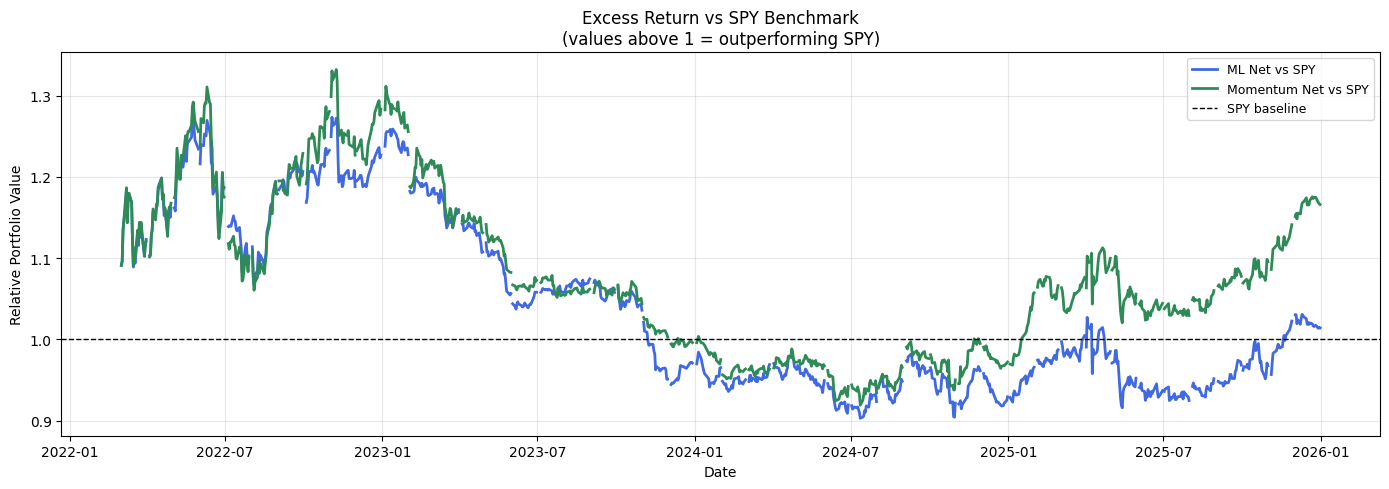

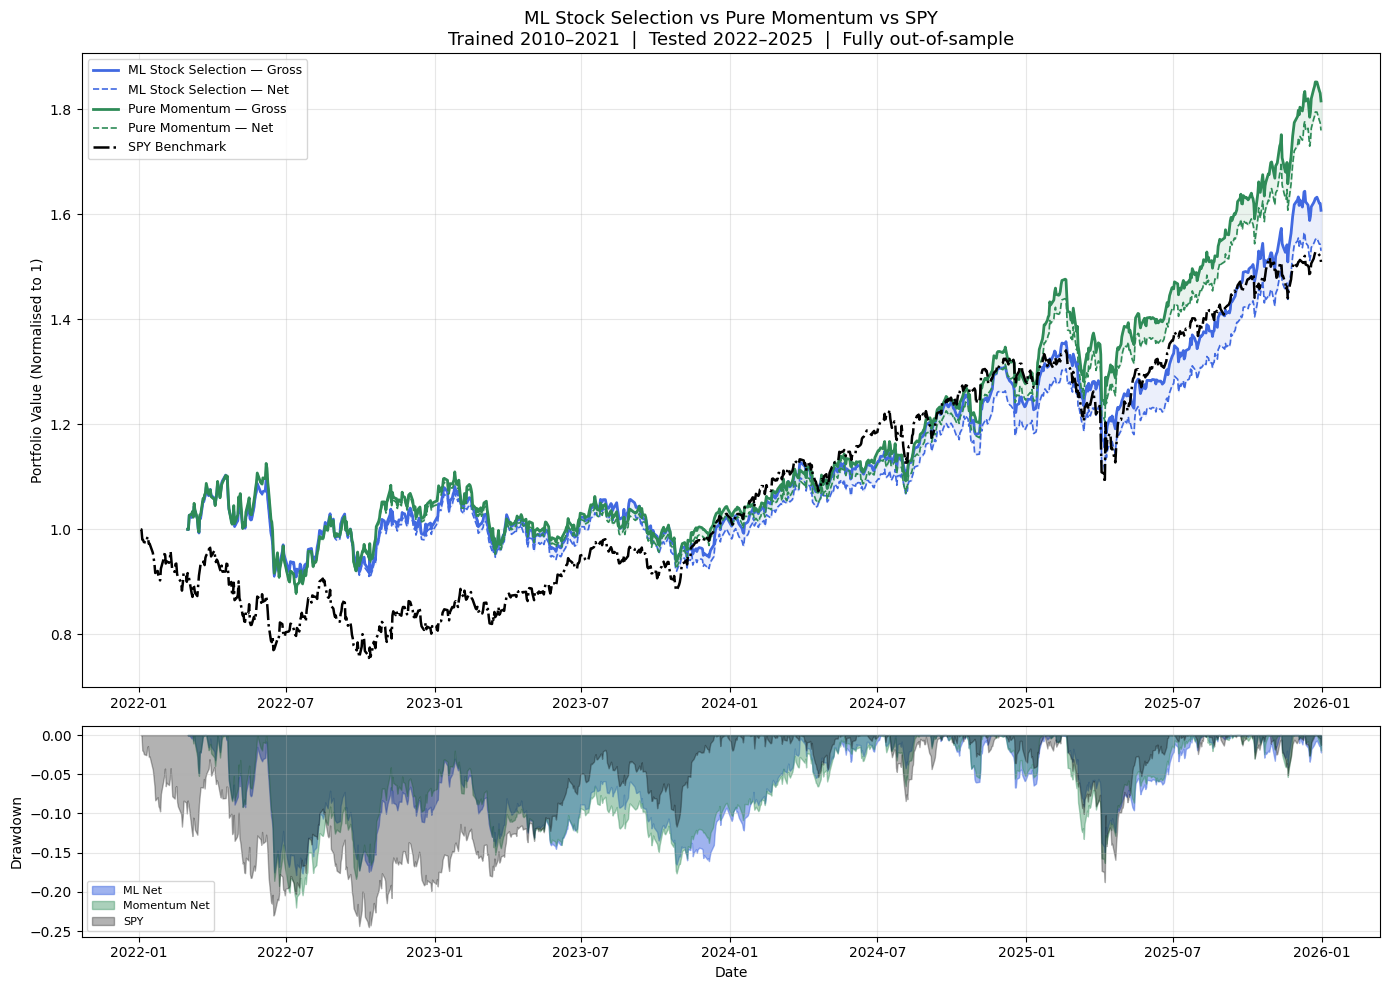


Done. Chart saved to backtest_result.png


In [13]:
#define cumulative value by cumulative returns
def to_cum(r):
    c = (1 + r).cumprod()
    return c / c.iloc[0]

#calculate drawdown
def calc_dd(c):
    return (c / c.cummax()) - 1

#convert the strategies into comulative curves
ml_gross_cum  = to_cum(ml_gross)
ml_net_cum    = to_cum(ml_net)
mom_gross_cum = to_cum(mom_gross)
mom_net_cum   = to_cum(mom_net)
spy_cum       = to_cum(spy_ret)

# Excess return over SPY (alpha isolation)
excess_ml  = ml_net_cum / spy_cum
excess_mom = mom_net_cum / spy_cum

fig2, ax = plt.subplots(figsize=(14, 5))
ax.plot(excess_ml,  label="ML Net vs SPY",        color="royalblue", linewidth=2.0)
ax.plot(excess_mom, label="Momentum Net vs SPY",   color="seagreen",  linewidth=2.0)
ax.axhline(1, color="black", linewidth=1.0, linestyle="--", label="SPY baseline")
ax.set_title("Excess Return vs SPY Benchmark\n(values above 1 = outperforming SPY)")
ax.set_ylabel("Relative Portfolio Value")
ax.set_xlabel("Date")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("excess_return.png", dpi=150, bbox_inches="tight")
plt.show()

#plotting the figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(ml_gross_cum,  label="ML Stock Selection — Gross",         color="royalblue", linewidth=2.0)
ax1.plot(ml_net_cum,    label="ML Stock Selection — Net",           color="royalblue", linewidth=1.2, linestyle="--")
ax1.plot(mom_gross_cum, label="Pure Momentum — Gross",              color="seagreen",  linewidth=2.0)
ax1.plot(mom_net_cum,   label="Pure Momentum — Net",                color="seagreen",  linewidth=1.2, linestyle="--")
ax1.plot(spy_cum,       label="SPY Benchmark",                      color="black",     linewidth=1.8, linestyle="-.")

ax1.fill_between(ml_gross_cum.index,  ml_net_cum,  ml_gross_cum,  alpha=0.10, color="royalblue")
ax1.fill_between(mom_gross_cum.index, mom_net_cum, mom_gross_cum, alpha=0.10, color="seagreen")

ax1.set_title(
    f"ML Stock Selection vs Pure Momentum vs SPY\n"
    f"Trained {TRAIN_START[:4]}–{TRAIN_END[:4]}  |  Tested {BACKTEST_START[:4]}–{BACKTEST_END[:4]}  |  Fully out-of-sample",
    fontsize=13
)
ax1.set_ylabel("Portfolio Value (Normalised to 1)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.fill_between(ml_net_cum.index,  calc_dd(ml_net_cum),  alpha=0.5, color="royalblue", label="ML Net")
ax2.fill_between(mom_net_cum.index, calc_dd(mom_net_cum), alpha=0.4, color="seagreen",  label="Momentum Net")
ax2.fill_between(spy_cum.index,     calc_dd(spy_cum),     alpha=0.3, color="black",     label="SPY")
ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Date")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("backtest_result.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nDone. Chart saved to backtest_result.png")


# Rolling Random Forest backtested version:

We are about to implement a rolling retraining process where the model is repeatedly updated using the most recent historical data instead of being trained just once at the beginning. At fixed intervals (every 6 months), we rebuild the training dataset, refit the Random Forest, and then use that updated model to generate new predictions going forward. This allows the strategy to continuously adapt to changing market conditions throughout the backtest, in hope of better portfolio performance.

[                       0%                       ]

[*********************100%***********************]  96 of 96 completed


Running backtests (2022–2025)...


[*********************100%***********************]  1 of 1 completed



--- Annual Performance (out-of-sample: 2022–2025) ---
-------------------------------------------------------------------------------------
ML Stock Selection (gross)                    | Return:  19.1% | Vol: 17.6% | Sharpe: 1.08 | MaxDD: -20.0%
ML Stock Selection (net)                      | Return:  17.3% | Vol: 17.6% | Sharpe: 0.98 | MaxDD: -20.1%
Pure Momentum (gross)                         | Return:  19.7% | Vol: 19.2% | Sharpe: 1.02 | MaxDD: -24.0%
Pure Momentum (net)                           | Return:  18.7% | Vol: 19.2% | Sharpe: 0.97 | MaxDD: -24.1%
SPY Benchmark                                 | Return:  11.1% | Vol: 18.0% | Sharpe: 0.61 | MaxDD: -24.5%


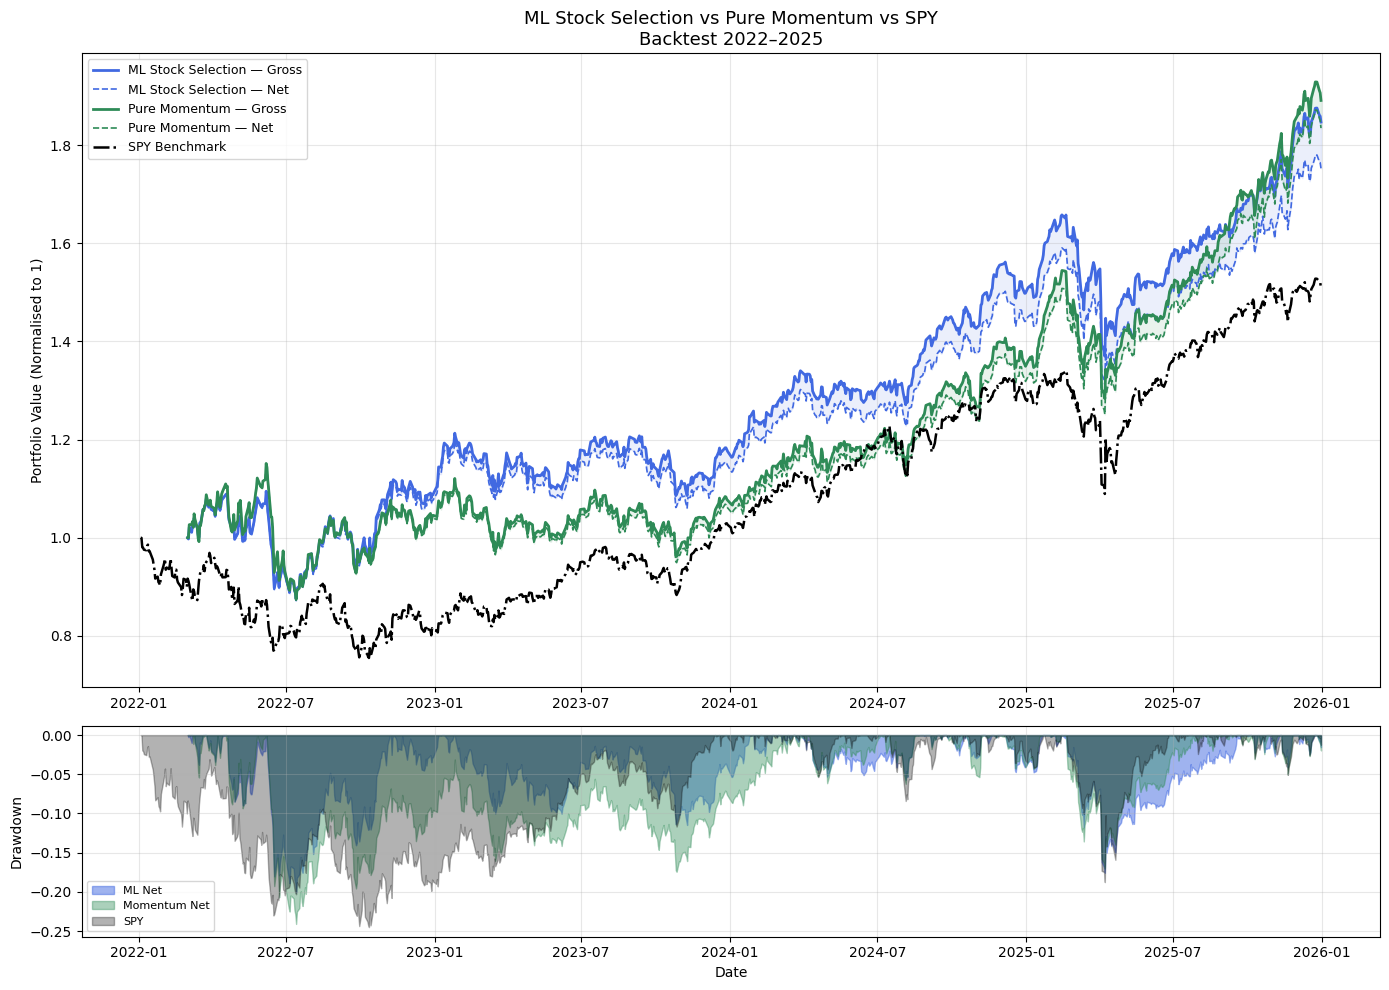


Done. Chart saved to backtest_result_rolling.png

Months evaluated (rolling):              46
Rolling Mean Information Coefficient (IC): 0.0107
Rolling IC Information Ratio (IC IR):      0.0467


In [17]:


# ============================================================
# BACKTEST FUNCTIONS
# ============================================================

def backtest_ml_selection_rolling(prices, retrain_months=6):
    dates = all_dates[(all_dates>=BACKTEST_START) & (all_dates<=BACKTEST_END)]
    pw, ps = None, None
    gross_rets, net_rets = [], []
    ic_rows = []  # records (date, stock, predicted_rank, actual_fwd_ret) for IC analysis

    last_train_end = pd.Timestamp(DOWNLOAD_START)
    rf_model = None

    for i in range(1,len(dates)-1):
        d,d2 = dates[i], dates[i+1]

        # retrain RF every retrain_months
        if rf_model is None or (d - last_train_end).days >= retrain_months*30:
            # FIX: expanding window. The original code set
            # `train_start = last_train_end` on every retrain after t
            # first, which meant each retrain only used the last
            # `retrain_months` of data instead of all history to date --
            # a much smaller, noisier training set than intended, and
            # inconsistent with the "model keeps its full memory and just
            # refreshes" narrative this section is making. Always training
            # from DOWNLOAD_START gives a true expanding window.
            train_start = pd.Timestamp(DOWNLOAD_START)
            train_end = d - pd.Timedelta(days=1)

            # generate training data
            train_dates = all_dates[(all_dates>=train_start) & (all_dates<=train_end)]
            X_rows, y_rows = [], []
            for j in range(1,len(train_dates)-1):
                dt, dt2 = train_dates[j], train_dates[j+1]
                p_slice = prices.loc[:dt]
                if len(p_slice)<200: continue
                mom = calc_mom_score(p_slice)
                if mom is None: continue
                candidates = mom.sort_values(ascending=False).head(CANDIDATES).index.tolist()
                mask = (prices.index>dt)&(prices.index<=dt2)
                fwd_rets = prices.loc[mask,candidates].pct_change().dropna()
                if len(fwd_rets)<2: continue
                fwd_mean = fwd_rets.mean()
                # Cross-sectional rank target (see main training section for
                # rationale): rank each month's candidates against each
                # other rather than predicting a raw return level.
                fwd_rank = fwd_mean.rank(pct=True)
                for stock in candidates:
                    f = stock_features(prices, dt, stock)
                    if f is None: continue
                    X_rows.append(f)
                    y_rows.append(float(fwd_rank[stock]))
            if len(X_rows)==0: continue
            X_df = pd.DataFrame(X_rows)
            y_arr = np.array(y_rows)
            rf_model = RandomForestRegressor(n_estimators=300, max_depth=4, min_samples_leaf=10, random_state=42, n_jobs=-1)
            rf_model.fit(X_df, y_arr)
            last_train_end = d

        p_slice = prices.loc[:d]
        if len(p_slice)<200: continue
        mom = calc_mom_score(p_slice)
        if mom is None: continue
        candidates = mom.sort_values(ascending=False).head(CANDIDATES).index.tolist()

        scored=[]
        for stock in candidates:
            f = stock_features(prices,d,stock)
            if f is None: continue
            pred = rf_model.predict(pd.DataFrame([f]))[0]
            scored.append((stock,pred))

        # Record actual forward returns for every scored candidate this
        # month (not just the ones selected) so IC reflects how well the
        # model ranked the whole candidate set.
        mask_all = (prices.index>d)&(prices.index<=d2)
        for stock, pred in scored:
            stock_path = prices.loc[mask_all, stock].dropna()
            if len(stock_path) < 2: continue
            actual_fwd_ret = float(stock_path.iloc[-1] / stock_path.iloc[0] - 1)
            ic_rows.append({"date": d, "stock": stock, "predicted_rank": pred, "actual_fwd_ret": actual_fwd_ret})

        if len(scored)<TOP_N:
            selected = candidates[:TOP_N]
        else:
            scored.sort(key=lambda x:x[1],reverse=True)
            selected = [s for s,_ in scored[:TOP_N]]

        w = calc_weights(prices,d,selected)
        if w is None: pw, ps = None, None; continue

        mask = (prices.index>d)&(prices.index<=d2)
        pp = prices.loc[mask,selected]
        if len(pp)<2: pw, ps = w, selected; continue

        r = pp.pct_change().dropna().mul(w, axis=1).sum(axis=1)
        gross_rets.append(r.copy())
        net_r = r.copy()
        if len(net_r)>0: net_r.iloc[0] -= turnover_cost(pw,ps,w,selected)
        net_rets.append(net_r)
        pw, ps = w, selected

    test_results_rolling = pd.DataFrame(ic_rows)
    return pd.concat(gross_rets).sort_index(), pd.concat(net_rets).sort_index(), test_results_rolling


def backtest_pure_momentum(prices):
    dates = all_dates[(all_dates>=BACKTEST_START) & (all_dates<=BACKTEST_END)]
    pw, ps = None, None
    gross_rets, net_rets = [], []

    for i in range(1,len(dates)-1):
        d,d2 = dates[i], dates[i+1]
        p_slice = prices.loc[:d]
        if len(p_slice)<200: continue
        mom = calc_mom_score(p_slice)
        if mom is None: continue
        s = mom.sort_values(ascending=False).head(TOP_N).index.tolist()
        w = calc_weights(prices,d,s)
        if w is None: continue
        mask = (prices.index>d)&(prices.index<=d2)
        pp = prices.loc[mask,s]
        if len(pp)<2: pw, ps=w,s; continue
        r = pp.pct_change().dropna().mul(w, axis=1).sum(axis=1)
        gross_rets.append(r.copy())
        net_r = r.copy()
        if len(net_r)>0: net_r.iloc[0] -= turnover_cost(pw,ps,w,s)
        net_rets.append(net_r)
        pw, ps = w,s

    return pd.concat(gross_rets).sort_index(), pd.concat(net_rets).sort_index()

# ============================================================
# RUN BACKTESTS
# ============================================================
print(f"Running backtests ({BACKTEST_START[:4]}\u2013{BACKTEST_END[:4]})...")
ml_gross, ml_net, test_results_rolling = backtest_ml_selection_rolling(prices, retrain_months=RETRAIN_MONTHS)
mom_gross, mom_net = backtest_pure_momentum(prices)

spy = yf.download("SPY", start=DOWNLOAD_START, auto_adjust=True)["Close"].ffill().squeeze()
spy_ret = spy.pct_change().dropna().loc[BACKTEST_START:BACKTEST_END]

# ============================================================
# PERFORMANCE METRICS
# ============================================================


print(f"\n--- Annual Performance (out-of-sample: {BACKTEST_START[:4]}\u2013{BACKTEST_END[:4]}) ---")
print("-"*85)
perf_stats(ml_gross,  "ML Stock Selection (gross)")
perf_stats(ml_net,    "ML Stock Selection (net)")
perf_stats(mom_gross, "Pure Momentum (gross)")
perf_stats(mom_net,   "Pure Momentum (net)")
perf_stats(spy_ret,   "SPY Benchmark")

# ============================================================
# PLOT
# ============================================================

def to_cum(r):
    c = (1+r).cumprod()
    return c/c.iloc[0]

def calc_dd(c):
    return (c/c.cummax())-1

ml_gross_cum = to_cum(ml_gross)
ml_net_cum   = to_cum(ml_net)
mom_gross_cum= to_cum(mom_gross)
mom_net_cum  = to_cum(mom_net)
spy_cum      = to_cum(spy_ret)

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(14,10), gridspec_kw={"height_ratios":[3,1]})
ax1.plot(ml_gross_cum, label="ML Stock Selection \u2014 Gross", color="royalblue", linewidth=2.0)
ax1.plot(ml_net_cum,   label="ML Stock Selection \u2014 Net", color="royalblue", linewidth=1.2, linestyle="--")
ax1.plot(mom_gross_cum,label="Pure Momentum \u2014 Gross", color="seagreen", linewidth=2.0)
ax1.plot(mom_net_cum,  label="Pure Momentum \u2014 Net", color="seagreen", linewidth=1.2, linestyle="--")
ax1.plot(spy_cum,      label="SPY Benchmark", color="black", linewidth=1.8, linestyle="-.")
ax1.fill_between(ml_gross_cum.index, ml_net_cum, ml_gross_cum, alpha=0.10, color="royalblue")
ax1.fill_between(mom_gross_cum.index, mom_net_cum, mom_gross_cum, alpha=0.10, color="seagreen")
ax1.set_title(f"ML Stock Selection vs Pure Momentum vs SPY\nBacktest {BACKTEST_START[:4]}\u2013{BACKTEST_END[:4]}", fontsize=13)
ax1.set_ylabel("Portfolio Value (Normalised to 1)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.fill_between(ml_net_cum.index, calc_dd(ml_net_cum), alpha=0.5, color="royalblue", label="ML Net")
ax2.fill_between(mom_net_cum.index, calc_dd(mom_net_cum), alpha=0.4, color="seagreen", label="Momentum Net")
ax2.fill_between(spy_cum.index, calc_dd(spy_cum), alpha=0.3, color="black", label="SPY")
ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Date")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("backtest_result_rolling.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nDone. Chart saved to backtest_result_rolling.png")

# ============================================================
# INFORMATION COEFFICIENT (ROLLING MODEL)
# ============================================================
from scipy.stats import spearmanr

ic_list_rolling = []
for date, group in test_results_rolling.groupby("date"):
    if len(group) > 1:
        corr, _ = spearmanr(group["predicted_rank"], group["actual_fwd_ret"])
        if not np.isnan(corr):
            ic_list_rolling.append(corr)

mean_ic_rolling = np.mean(ic_list_rolling)
ic_std_rolling  = np.std(ic_list_rolling)
ic_ir_rolling   = mean_ic_rolling / ic_std_rolling if ic_std_rolling > 0 else np.nan

print(f"\nMonths evaluated (rolling):              {len(ic_list_rolling)}")
print(f"Rolling Mean Information Coefficient (IC): {mean_ic_rolling:.4f}")
print(f"Rolling IC Information Ratio (IC IR):      {ic_ir_rolling:.4f}")



# **Performance of the Machine Learning Strategy**

Pure momentum edged out the ML strategy on raw return (18.3%/19.7% vs. 14.5%/19.1%) gross, but the ML layer's real strength shows up on a risk-adjusted basis. The rolling-retrained model delivers a better Sharpe ratio (1.08 vs. 1.02) and a shallower max drawdown (-20.0% vs. -24.0%) than pure momentum - and crucially, this isn't just a smoother equity curve by chance. Across 46 months of out-of-sample evaluation, the rolling model shows a small but genuinely positive Information Coefficient (mean IC of 0.0107, IC IR of 0.0467), confirming it's extracting real, if modest, predictive signal rather than just riding momentum's coattails. The static model, by contrast, shows a slightly negative IC (-0.0024, IC IR -0.0101) - statistically indistinguishable from zero skill - which lines up with its weaker Sharpe (0.87 gross) and makes the rolling model's positive IC a meaningful result rather than an artifact of the setup.

Survivorship bias is worth being upfront about: the universe is built from companies that are large and successful today, backfilled to 2009, so any company that got delisted, went bankrupt, or fell out of the large-cap space along the way is invisible to the backtest. This almost certainly inflates every strategy here - ML, momentum, and SPY alike - so these numbers are best read as a ceiling on realistic performance rather than something directly achievable.

Sharpe ratio is also a fairly blunt tool for this comparison, since it ignores correlations between stocks and can get unstable at low volatility. Mean-variance optimisation or risk parity would be a more principled way to weight the portfolio, though with this amount of data that brings its own overfitting risk.

# **Retraining Impact**

The gap between the static and rolling models is the clearest and most interesting finding in this project. A model trained once on 2010–2021 and never updated underperforms pure momentum on both return and Sharpe, and shows no measurable predictive skill by the time it's tested on 2022–2025. Retrain that same architecture every six months on an expanding window, and it not only closes the gap with momentum but beats it on Sharpe and drawdown, while recovering a small positive IC. Since both experiments use an identical stock universe, this difference is attributable to the retraining process itself - strong evidence that feature-return relationships genuinely drift over time, and that a model needs to keep learning to stay useful.


# **ML vs. Pure Momentum**

Pure momentum is a blunt instrument: buy whatever has gone up recently, without asking whether the move is stable or about to reverse. The ML layer adds real structure on top of that - rewarding consistency, penalising rising volatility, factoring in drawdown and relative strength - and the positive IC confirms this structure is picking up genuine signal, not just noise that happens to look good in one backtest. That's why it wins on risk-adjusted terms even without beating momentum on raw return: it's a more risk-aware way of expressing the same underlying trend-following idea.


# **Overall Assessment**

The rolling-retrained ML strategy is the strongest version tested here. It's the only version with a positive, validated skill metric behind it, and it translates that into better risk-adjusted returns and materially better drawdown control than momentum alone, a real edge, even if a modest one. The core finding is that a feature-driven ML layer, refreshed periodically and validated with a proper skill metric rather than just an equity curve, produces a demonstrably more risk-aware strategy than momentum by itself.

# **Limitations and Open Questions**

A few things temper how far these results should be taken. With only 46 months evaluated and an IC Information Ratio of 0.0467, the monthly IC is noisy relative to its mean, so a Mean IC of 0.0107 - while genuinely positive - isn't large enough to claim with full statistical confidence given the sample size. Results also come from a single random seed and a single backtest path, so there's no direct measure of how much noise sits inside the reported Sharpe ratios. The rel_strength feature is measured against the same survivorship-biased universe used everywhere else, so that bias leaks into a model input as well as the backtest results themselves. None of this undermines the core comparison between strategies, but the absolute numbers, and the IC figure especially, are best treated as indicative of a real, modest edge rather than a fully validated one.

# **Survivorship Bias**

The stock universe in this project consists of large-cap US equities that are currently trading, backfilled to 2009. Like most backtests built on free data, this introduces some survivorship bias: companies delisted, acquired, or bankrupted during the period aren't captured, which likely flatters the absolute returns of every strategy tested here, including the SPY benchmark. The relative comparison between ML, momentum, and SPY should still hold up reasonably well since all three face the same universe, but the absolute return figures are best read as an optimistic upper bound rather than something directly achievable in practice. A more rigorous version of this project would use point-in-time index constituent data (including delisted names), though that typically requires paid datasets beyond what's freely available.